# Data Generation

## Coordinate Transformation

This section define vector and coordinate transformations.

In [1]:
import numpy as np
from typing import List

def convert_heading_speed_to_neu_speed(
    azimuth: float,
    ground_speed: float,
    vertical_speed: float
):

  # Compute NEU velocity components
  v_n = ground_speed * np.cos(azimuth)
  v_e = ground_speed * np.sin(azimuth)
  v_u = vertical_speed
  return v_n, v_e, v_u


def convert_neu_vec_to_ecef_vec(
    n_vector: List[float],
    e_vector: List[float],
    u_vector: List[float],
    v_n: float,
    v_e: float,
    v_u: float
):

  # Ensure NEU vectors are normalized
  n_vector /= np.linalg.norm(n_vector)
  e_vector /= np.linalg.norm(e_vector)
  u_vector /= np.linalg.norm(u_vector)

  # Transformation matrix NEU -> ECEF
  T_neu_to_ecef = np.vstack([n_vector, e_vector, u_vector]).T

  # Create a NEU velocity vector.
  v_neu = np.array([v_n, v_e, v_u])

  # Convert to ECEF
  v_ecef = T_neu_to_ecef @ v_neu

  print("NEU Vector:", v_neu)
  print("ECEF Vector:", v_ecef)
  return v_ecef[0], v_ecef[1], v_ecef[2]

def convert_heading_speed_to_ecef_vel(
    n_vector: List[float],
    e_vector: List[float],
    u_vector: List[float],
    azimuth: float,
    ground_speed: float,
    vertical_speed: float
):
  """
  Converts an NEU speed represented by azimuth, ground speed and vertical speed to .

    Parameters:
        n_vector: A vector representing the North direction in ECEF coordinates.
        e_vector: A vector representing the East direction in ECEF coordinates.
        u_vector: A vector representing the Up direction in ECEF coordinates.
        azimuth: The ground speed azimuth from North in radians.
        ground_speed: The speed in the North-East plane.
        vertical_speed: The speed in the Up direction.

    Returns:
        tuple: (v_x, v_y, v_z) velocity in ECEF cooridnates.
  """
  v_n, v_e, v_u = convert_heading_speed_to_neu_speed(
      azimuth,
      ground_speed,
      vertical_speed
  )
  return convert_neu_vec_to_ecef_vec(
      n_vector,
      e_vector,
      u_vector,
      v_n,
      v_e,
      v_u
  )


def ecef_enu_vectors(latitude: float, longitude: float, altitude: float = 0.0):
  """
  Compute the East, North, and Up unit vectors in ECEF for a given geographic location.

  Parameters:
      latitude (float): Latitude in degrees.
      longitude (float): Longitude in degrees.
      altitude (float): Altitude in meters (default is 0).

  Returns:
      tuple: (north_vector, east_vector, up_vector), each a unit vector in ECEF coordinates.
  """
  # Convert degrees to radians
  lat_rad = np.radians(latitude)
  lon_rad = np.radians(longitude)

  # WGS84 ellipsoid constants
  a = 6378137.0  # Semi-major axis (m)
  b = 6356752.314245  # Semi-minor axis (m)
  e2 = 1 - (b*2 / a*2)  # Eccentricity squared

  # Radius of curvature in the prime vertical
  N = a / np.sqrt(1 - e2 * np.sin(lat_rad)**2)

  # ECEF coordinates for the point (for reference)
  x = (N + altitude) * np.cos(lat_rad) * np.cos(lon_rad)
  y = (N + altitude) * np.cos(lat_rad) * np.sin(lon_rad)
  z = (N * (1 - e2) + altitude) * np.sin(lat_rad)

  # Up vector (normalized normal to the ellipsoid)
  up_vector = np.array([x, y, z])
  up_vector /= np.linalg.norm(up_vector)

  # East vector (perpendicular to Up, pointing east)
  east_vector = np.array([-np.sin(lon_rad), np.cos(lon_rad), 0])
  east_vector /= np.linalg.norm(east_vector)  # Ensure it's a unit vector

  # North vector (perpendicular to both Up and East)
  north_vector = np.cross(up_vector, east_vector)
  north_vector /= np.linalg.norm(north_vector)  # Ensure it's a unit vector

  return north_vector, east_vector, up_vector

def lla_to_ecef(lat, lon, alt):
    """
    Converts latitude, longitude, and altitude to ECEF (Earth-Centered Earth-Fixed) coordinates.

    Parameters:
    - lat (float): Latitude in degrees
    - lon (float): Longitude in degrees
    - alt (float): Altitude above the WGS84 ellipsoid in meters

    Returns:
    - tuple: ECEF coordinates (X, Y, Z) in meters
    """
    # Convert latitude and longitude from degrees to radians
    lat = np.deg2rad(lat)
    lon = np.deg2rad(lon)

    # WGS84 ellipsoid constants
    a = 6378137.0            # Semi-major axis in meters
    f = 1 / 298.257223563    # Flattening
    e2 = f * (2 - f)         # Square of eccentricity

    # Prime vertical radius of curvature
    N = a / np.sqrt(1 - e2 * np.sin(lat)**2)

    # ECEF coordinates
    x = (N + alt) * np.cos(lat) * np.cos(lon)
    y = (N + alt) * np.cos(lat) * np.sin(lon)
    z = (N * (1 - e2) + alt) * np.sin(lat)

    return x, y, z

## Objects

This section define structures needed to create simulated data

In [2]:
from typing import Tuple, ClassVar, List
from numpy import typing as npt
from dataclasses import dataclass, field



@dataclass
class TrackState:
  id: str
  t: float
  x: float
  y: float
  z: float

@dataclass
class Target:

  # free fall acceleration
  g: ClassVar[float] = 9.8

  id: str
  t0: float
  lat: float # in degrees
  lon: float # in degrees
  azimuth: float # in degrees
  ground_speed: float # in m/s
  vertical_speed: float # in m/s
  n_vec: Tuple[float, float, float] = field(init=False)
  e_vec: Tuple[float, float, float] = field(init=False)
  u_vec: Tuple[float, float, float] = field(init=False)
  x: float = field(init=False)
  y: float = field(init=False)
  z: float = field(init=False)
  vx: float = field(init=False)
  vy: float = field(init=False)
  vz: float = field(init=False)
  ax: float = field(init=False)
  ay: float = field(init=False)
  az: float = field(init=False)

  def __post_init__(self):
    self.n_vec, self.e_vec, self.u_vec = ecef_enu_vectors(self.lat, self.lon)
    self.vx, self.vy, self.vz = convert_heading_speed_to_ecef_vel(
        self.n_vec,
        self.e_vec,
        self.u_vec,
        self.azimuth,
        self.ground_speed,
        self.vertical_speed
    )
    self.x, self.y, self.z = lla_to_ecef(self.lat, self.lon, 0)
    self.ax, self.ay, self.az = convert_neu_vec_to_ecef_vec(
        self.n_vec,
        self.e_vec,
        self.u_vec,
        0.0,
        0.0,
        -self.g
    )

@dataclass
class Sensor:
  """

  Attributes:
    system_id: The id of the sensor.
    error_x: Standard diviation of error in x axis.
    error_y: Standard diviation of error in y axis.
    error_z: Standard diviation of error in z axis.
    rate: Detection rate.
  """

  system_id: str
  error_x: float
  error_y: float
  error_z: float
  rate: float

In [3]:
from typing import List
import csv
import numpy as np

@dataclass
class Scenario:
  # progress matrix
  pm: ClassVar = lambda self, dt : np.array([[1,   dt,   0.5*dt*dt,    0,   0,          0,        0,   0,          0],
                                            [0,    1,          dt,    0,   0,          0,        0,   0,          0],
                                            [0,    0,           1,    0,   0,          0,        0,   0,          0],
                                            [0,    0,           0,    1,  dt,  0.5*dt*dt,        0,   0,          0],
                                            [0,    0,           0,    0,   1,         dt,        0,   0,          0],
                                            [0,    0,           0,    0,   0,          1,        0,   0,          0],
                                            [0,    0,           0,    0,   0,          0,        1,  dt,  0.5*dt*dt],
                                            [0,    0,           0,    0,   0,          0,        0,   1,         dt],
                                            [0,    0,           0,    0,   0,          0,        0,   0,          1]])

  # The detection delay (in seconds from start).
  delay: ClassVar[int] = 5

  targets: List[Target]
  sensors: List[Sensor]

  def create_scenario_csv(self, file_path: str):
    plot_id = 1000
    with open(file_path, 'w') as f:
      writer = csv.writer(f)
      writer.writerow(['system_id', 'plot_id', 't', 'x', 'y', 'z', 'sig_x', 'sig_y', 'sig_z', 'target_id'])
      for target in self.targets:
        for sensor in self.sensors:
          plot_id+=1
          #plot_id = 1000
          # TODO: calculate the acceleration vector.
          sv = np.array([[target.x],
                         [target.vx],
                         [target.ax],
                         [target.y],
                         [target.vy],
                         [target.ay],
                         [target.z],
                         [target.vz],
                         [target.az]])
          curr_time = target.t0 + self.delay
          hit_ground = False
          # simulate the target flight as detected by the
          while not hit_ground:
            dt = curr_time - target.t0
            pos = np.dot(self.pm(dt), sv)
            if pos[6][0] < target.z:  # meaning the target hit the ground
              hit_ground = True
            else: # appending the noised detection to the csv file
              x = pos[0][0] + np.random.normal(0, sensor.error_x)
              y = pos[3][0] + np.random.normal(0, sensor.error_y)
              z = pos[6][0] + np.random.normal(0, sensor.error_z)
              writer.writerow([sensor.system_id, str(plot_id), curr_time, x, y, z,
                               sensor.error_x, sensor.error_y, sensor.error_z, target.id])
            plot_id += 1
            curr_time += 1/sensor.rate

In [17]:
import os
sensor_1 = Sensor(1, 500, 500, 500, 1/1.5)

sensor_2 = Sensor(2, 700, 750, 600, 1/3.)

sensor_3 = Sensor(3, 600, 800, 600, 1/2)

target_1 = Target(1, 0, 31.537530, 34.469916, 90, 100, 950)

target_2 = Target(2, 10, 31.40004705509903, 34.37381998844323,85, 100, 900)

target_3 = Target(3, 0, 31.56, 34.42,110, 90, 800)

target_4 = Target(4, 20,31.538270449065784,34.53372731684932,100, 80, 750)

target_5 = Target(5, 0,31.324326244355138,34.3322618721268,110, 80, 750)

target_6 = Target(6, 20,31.324326244355132,34.3322618721270,110, 100, 900)

target_7 = Target(7, 10,31.32668549103798,34.335866761042816,95, 100, 800)

target_8 = Target(8, 10,31.546380263060502,34.515861581503835,95, 100, 800)

target_9 = Target(9, 10,31.51301956783522,34.50968177193352,95, 100, 800)

target_10 = Target(10, 10,31.469105757607032,34.471916269003835,95, 100, 800)

target_11 = Target(11, 10,31.22522097327449,34.27235634345932,95, 100, 800)

trial_scenario = Scenario([target_1,target_2,target_3,target_4,target_5,target_6,target_7,target_8,target_9,target_10], [sensor_1, sensor_2, sensor_3])


# Construct the full file path
trial_scenario_name = '25.6.2025'

basedir = os.getcwd()

trial_scenario_name_path = os.path.join(basedir,f'{trial_scenario_name}', 'plots.csv')

# Assuming trial_scenario is your object
trial_scenario.create_scenario_csv(trial_scenario_name_path)


NEU Vector: [-44.80736161  89.39966636 950.        ]
ECEF Vector: [655.74016805 395.82103906 570.81567695]
NEU Vector: [ 0.   0.  -9.8]
ECEF Vector: [-6.89861582 -4.73595602 -5.10096269]
NEU Vector: [-98.43766434 -17.60756199 900.        ]
ECEF Vector: [698.30965687 358.40940997 451.55987196]
NEU Vector: [ 0.   0.  -9.8]
ECEF Vector: [-6.91660092 -4.73125486 -5.08093094]
NEU Vector: [-89.9118732   -3.98184103 800.        ]
ECEF Vector: [615.88849783 313.02835431 413.27304248]
NEU Vector: [ 0.   0.  -9.8]
ECEF Vector: [-6.90109344 -4.72881647 -5.10423393]
NEU Vector: [ 68.98550978 -40.50925129 750.        ]
ECEF Vector: [505.81017858 431.81362404 355.79918119]
NEU Vector: [ 0.   0.  -9.8]
ECEF Vector: [-6.89328288 -4.74359893 -5.1010705 ]
NEU Vector: [-79.92166507  -3.53941425 750.        ]
ECEF Vector: [576.6039504  297.02534094 384.9725071 ]
NEU Vector: [ 0.   0.  -9.8]
ECEF Vector: [-6.92555264 -4.73000813 -5.06988596]
NEU Vector: [-99.90208133  -4.42426781 900.        ]
ECEF Vector:

C:\Users\roeep\AppData\Local\Temp\ipykernel_24084\1366563783.py:9: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



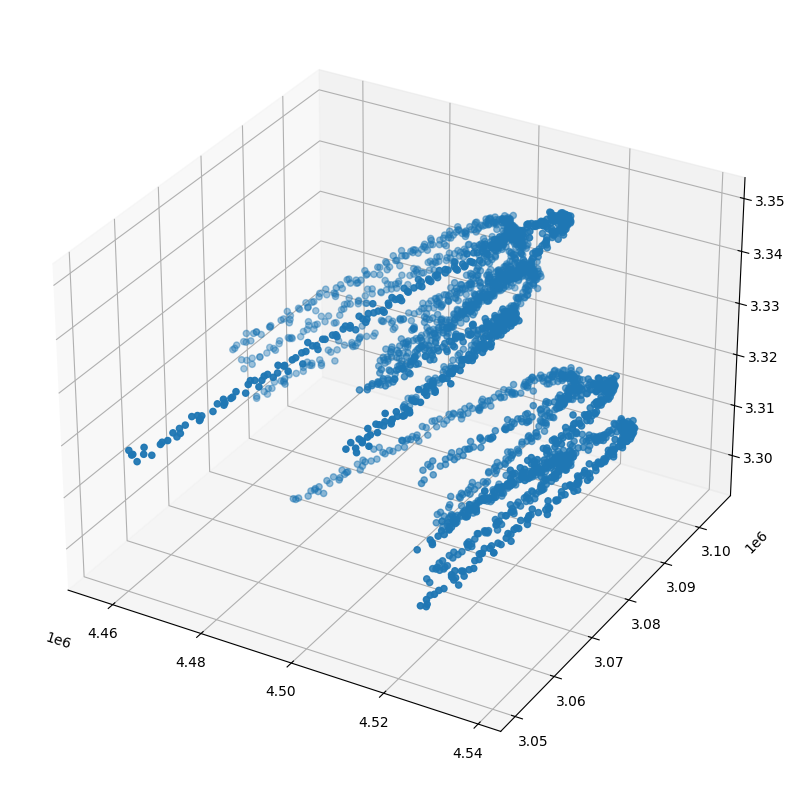

In [18]:
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(trial_scenario_name_path)
fig = plt.figure()
ax = plt.axes(projection='3d')
plt.rcParams['figure.figsize'] = [15, 10]
ax.scatter3D(df['x'].values, df['y'].values, df['z'].values, cmap='Greens')

In [12]:
import plotly.express as px
import pandas as pd



# Create a 3D scatter plot
fig = px.scatter_3d(df, x='x', y='y', z='z', title="3D Scatter Plot")

# Show the plot in the browser
fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

C:\Users\roeep\AppData\Local\Temp\ipykernel_24084\1946527962.py:28: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



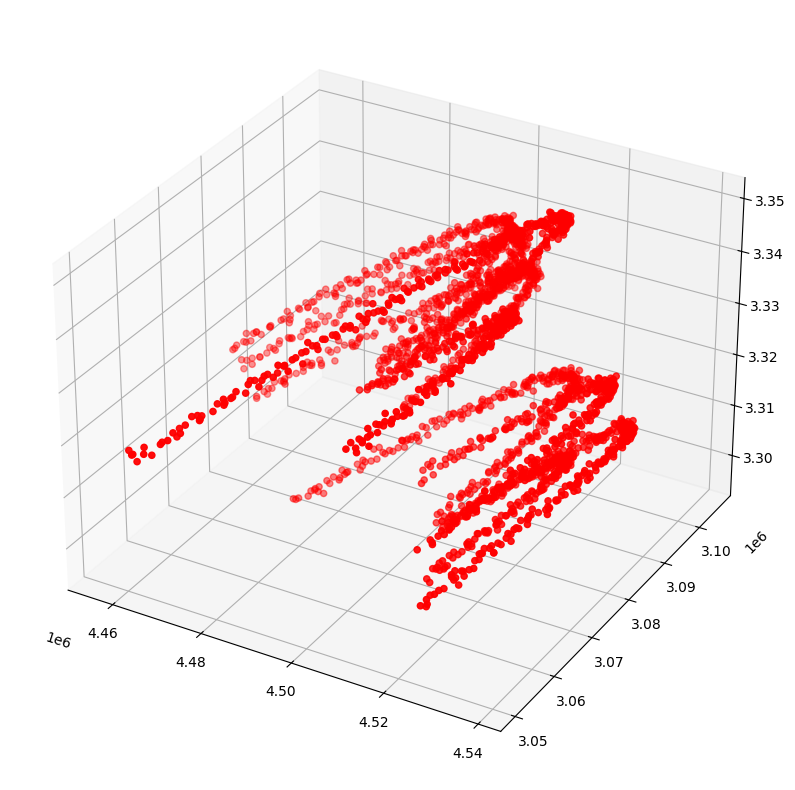

<Figure size 1500x1000 with 0 Axes>

In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ecef_coords = df[['x', 'y', 'z']].values

# Plot ECEF data
x, y, z = zip(*ecef_coords)
ax.scatter(x, y, z, c='r', marker='o', label='ECEF Data')

# Plot Earth's surface (optional for reference)
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
earth_x = 6378137 * np.outer(np.cos(u), np.sin(v))
earth_y = 6378137 * np.outer(np.sin(u), np.sin(v))
earth_z = 6378137 * np.outer(np.ones(np.size(u)), np.cos(v))
fig = plt.figure()
ax = Axes3D(fig)
ax.plot_surface(earth_x, earth_y, earth_z, color='b', alpha=0.3)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.legend()
plt.show()

In [20]:
import numpy as np
# Assuming df is your DataFrame with ECEF columns x, y, z
def ecef_to_lla(x, y, z):
    a = 6378137  # Equatorial radius
    f = 1 / 298.257223563  # Flattening
    e2 = 2 * f - f ** 2  # Eccentricity squared
    b = a * (1 - f)
    ep = np.sqrt((a ** 2 - b ** 2) / (b ** 2))

    p = np.sqrt(x ** 2 + y ** 2)
    theta = np.arctan2(z * a, p * b)

    lon = np.arctan2(y, x)
    lat = np.arctan2(z + ep ** 2 * b * np.sin(theta) ** 3, p - e2 * a * np.cos(theta) ** 3)
    N = a / np.sqrt(1 - e2 * np.sin(lat) ** 2)
    alt = p / np.cos(lat) - N

    lat = np.degrees(lat)
    lon = np.degrees(lon)
    return lat, lon, alt


def ecef_enu_vectors(latitude, longitude, altitude=0):
    """
    Compute the East, North, and Up unit vectors in ECEF for a given geographic location.
    
    Parameters:
        latitude: Latitude in degrees.
        longitude: Longitude in degrees.
        altitude: Altitude in meters (default is 0).
    
    Returns:
        tuple: (east_vector, north_vector, up_vector), each a unit vector in ECEF coordinates.
    """
    # Convert degrees to radians
    lat_rad = np.radians(latitude)
    lon_rad = np.radians(longitude)
    
    # WGS84 ellipsoid constants
    a = 6378137.0  # Semi-major axis (m)
    b = 6356752.314245  # Semi-minor axis (m)
    e2 = 1 - (b**2 / a**2)  # Eccentricity squared
    
    # Radius of curvature in the prime vertical
    N = a / np.sqrt(1 - e2 * np.sin(lat_rad)**2)
    
    # ECEF coordinates for the point (for reference)
    x = (N + altitude) * np.cos(lat_rad) * np.cos(lon_rad)
    y = (N + altitude) * np.cos(lat_rad) * np.sin(lon_rad)
    z = (N * (1 - e2) + altitude) * np.sin(lat_rad)
    
    # Up vector (normalized normal to the ellipsoid)
    up_vector = np.array([x, y, z])
    up_vector /= np.linalg.norm(up_vector)
    
    # East vector (perpendicular to Up, pointing east)
    east_vector = np.array([-np.sin(lon_rad), np.cos(lon_rad), 0])
    east_vector /= np.linalg.norm(east_vector)  # Ensure it's a unit vector
    
    # North vector (perpendicular to both Up and East)
    north_vector = np.cross(up_vector, east_vector)
    north_vector /= np.linalg.norm(north_vector)  # Ensure it's a unit vector
    
    return east_vector, north_vector, up_vector

In [21]:

df = pd.read_csv(trial_scenario_name_path)
print(df)
# Apply the ecef_to_lla function to each row of the DataFrame
df[['latitude', 'longitude', 'altitude']] = df.apply(
    lambda row: pd.Series(ecef_to_lla(row['x'], row['y'], row['z'])),
    axis=1
)
    # Define a function to map sensor_id to a color

df.to_csv(trial_scenario_name_path, index=False)  # index=False prevents the DataFrame index from being saved as a separate column

      system_id  plot_id      t             x             y             z  \
0             1     1001    5.0  4.487690e+06  3.082132e+06  3.319914e+06   
1             1     1002    6.5  4.489620e+06  3.082332e+06  3.320812e+06   
2             1     1003    8.0  4.491089e+06  3.083352e+06  3.321472e+06   
3             1     1004    9.5  4.492450e+06  3.083250e+06  3.321645e+06   
4             1     1005   11.0  4.492309e+06  3.083684e+06  3.323240e+06   
...         ...      ...    ...           ...           ...           ...   
2606          3     3665  187.0  4.468166e+06  3.082612e+06  3.314629e+06   
2607          3     3666  189.0  4.465620e+06  3.081561e+06  3.313198e+06   
2608          3     3667  191.0  4.465740e+06  3.082102e+06  3.312598e+06   
2609          3     3668  193.0  4.463739e+06  3.080371e+06  3.312000e+06   
2610          3     3669  195.0  4.462864e+06  3.081052e+06  3.310203e+06   

      sig_x  sig_y  sig_z  target_id  
0       500    500    500          1

create demo plots correlations


In [22]:
import pandas as pd
import os

# Function to assign STN values
def assign_stn(dataframe):
    """Assigns STN values cyclically within each system_id group."""
    dataframe['STN'] = None
    
    # Group by system_id and assign STN values cyclically
    for system_id, group in dataframe.groupby('system_id'):
        group_len = len(group)
        chunk_size = group_len // 3
        remainder = group_len % 3

        # Assign values for the first 3 chunks
        stn_values = []
        for i in range(3):
            stn_values.extend([i + 1] * chunk_size)

        # Assign remaining values to the last STN group
        stn_values.extend([3] * remainder)

        # Update the dataframe
        dataframe.loc[group.index, 'STN'] = stn_values

    return dataframe

# Function to create a plot correlations CSV file
def create_correlations_csv(dataframe, output_file="plot_correlations.csv"):
    """Creates a plot_correlations.csv file mapping plot_id to track_id."""
    correlations = dataframe[['plot_id', 'system_id', 'STN']].copy()
    correlations = correlations.iloc[0:100]
    correlations.rename(columns={'plot_id': 'plot_id', 'STN': 'track_id'}, inplace=True)

    # Save the correlations DataFrame
    correlations.to_csv(output_file, index=False)
    print(f"Plot correlations file saved to: {output_file}")

# Define the events directory and file path
csv_file = trial_scenario_name_path

# Load the CSV into a DataFrame
data = pd.read_csv(csv_file)

# Assign STN to the DataFrame
data = assign_stn(data)

# Save the updated DataFrame
updated_file = "plots.csv"
data.to_csv(updated_file, index=False)
print(f"Updated file with STN column saved to: {updated_file}")

# Generate the plot correlations CSV file
create_correlations_csv(data)


Updated file with STN column saved to: plots.csv
Plot correlations file saved to: plot_correlations.csv


In [ ]:
df = pd.read_csv(trial_scenario_name)
print(df)
# Apply the ecef_to_lla function to each row of the DataFrame
df[['latitude', 'longitude', 'altitude']] = df.apply(
    lambda row: pd.Series(ecef_to_lla(row['x'], row['y'], row['z'])),
    axis=1
)
    # Define a function to map sensor_id to a color

df.to_csv(trial_scenario_name, index=False)  # index=False prevents the DataFrame index from being saved as a separate column


#make_events()
event_id = '6.3.2025'
EVENTS_DIR = os.path.join(os.path.dirname(__file__), 'events')
event_file = os.path.join(EVENTS_DIR, f'{event_id}', 'plots.csv')

df = pd.read_csv(event_file)
print(df)
# Apply the ecef_to_lla function to each row of the DataFrame
df[['latitude', 'longitude', 'altitude']] = df.apply(
lambda row: pd.Series(ecef_to_lla(row['x'], row['y'], row['z'])),
axis=1
)
# Define a function to map sensor_id to a color

df.to_csv(event_file, index=False)  # index=False prevents the DataFrame index from being saved as a separate column